<a href="https://colab.research.google.com/github/akshithasamudrala9515/TASK_TNSIF_AI-ML/blob/main/UnsupervisedLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Unsupervised learning**

k-means clustering

   Experience  Salary  Cluster
0           1   25000        2
1           2   28000        2
2           3   32000        2
3           5   45000        0
4           6   50000        0
5           8   65000        0
6          10   80000        0
7          12   90000        1
8          15  110000        1
9          18  130000        1


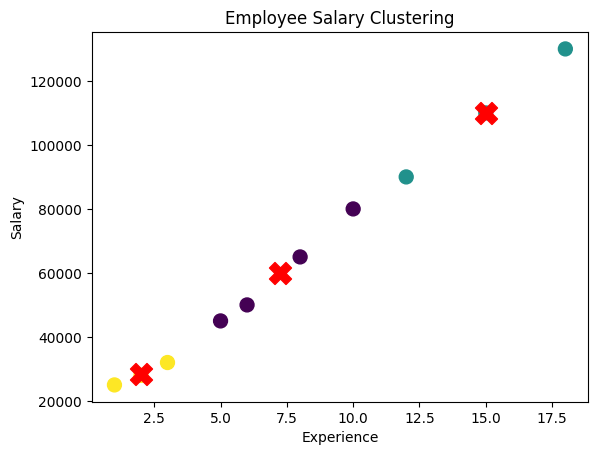

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

data = {
    "Experience":[1,2,3,5,6,8,10,12,15,18],
    "Salary":[25000,28000,32000,45000,50000,65000,80000,90000,110000,130000]
}

df = pd.DataFrame(data)

kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(df)

print(df)

plt.scatter(df["Experience"], df["Salary"],
            c=df["Cluster"], s=100)

plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            color='red',
            marker='X',
            s=250)

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Employee Salary Clustering")
plt.show()

Saving income.csv to income.csv
        Name  Age  Income  Cluster
0        Rob   27   70000        1
1    Michael   29   90000        2
2      Mohan   29   61000        1
3     Ismail   28   60000        1
4       Kory   42  150000        0
5     Gautam   39  155000        0
6      David   41  160000        0
7     Andrea   38  162000        0
8       Brad   36  156000        0
9   Angelina   35  130000        0
10    Donald   37  137000        0
11       Tom   26   45000        1
12    Arnold   27   48000        1
13     Jared   28   51000        1
14     Stark   29   49500        1
15    Ranbir   32   53000        1
16    Dipika   40   65000        1
17  Priyanka   41   63000        1
18      Nick   43   64000        1
19      Alia   39   80000        2
20       Sid   41   82000        2
21     Abdul   39   58000        1


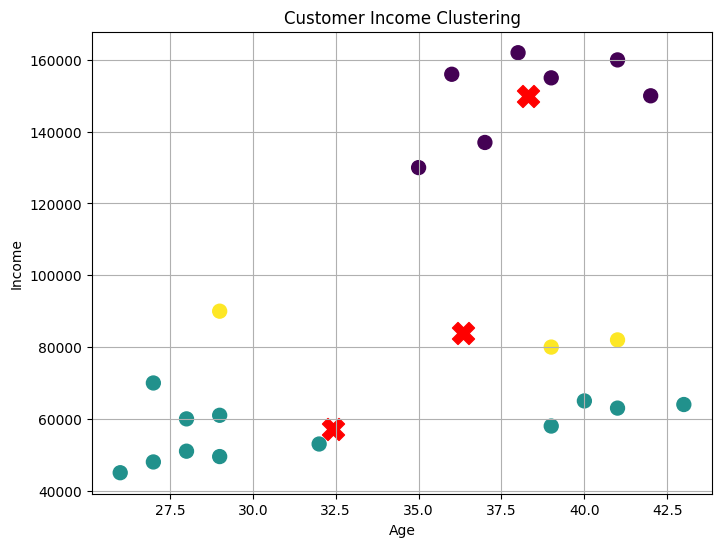

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from google.colab import files

# Upload dataset
uploaded = files.upload()

# Read uploaded CSV file
df = pd.read_csv(next(iter(uploaded)))

# Select numerical columns for clustering
X = df[["Age", "Income"]]

# Create K-Means model
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit the model and assign cluster labels
df["Cluster"] = kmeans.fit_predict(X)

# Display dataset with clusters
print(df)

# Plot the clusters
plt.figure(figsize=(8,6))

plt.scatter(df["Age"], df["Income"],
            c=df["Cluster"],
            s=100)

# Plot cluster centroids
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            color='red',
            marker='X',
            s=250)

plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Customer Income Clustering")
plt.grid(True)

plt.show()

DBSCAN

Saving income.csv to income (1).csv
        Name  Age  Income  Cluster
0        Rob   27   70000        0
1    Michael   29   90000        0
2      Mohan   29   61000        0
3     Ismail   28   60000        0
4       Kory   42  150000        1
5     Gautam   39  155000        1
6      David   41  160000        1
7     Andrea   38  162000        1
8       Brad   36  156000        1
9   Angelina   35  130000        1
10    Donald   37  137000        1
11       Tom   26   45000        0
12    Arnold   27   48000        0
13     Jared   28   51000        0
14     Stark   29   49500        0
15    Ranbir   32   53000        0
16    Dipika   40   65000        2
17  Priyanka   41   63000        2
18      Nick   43   64000        2
19      Alia   39   80000        2
20       Sid   41   82000        2
21     Abdul   39   58000        2


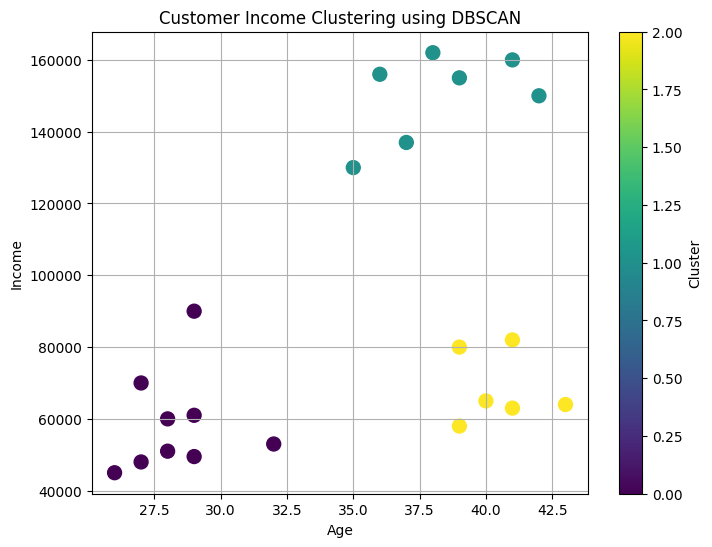

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from google.colab import files

# Upload dataset
uploaded = files.upload()

# Read uploaded CSV file
df = pd.read_csv(next(iter(uploaded)))

# Select numerical columns
X = df[["Age", "Income"]]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=2)
df["Cluster"] = dbscan.fit_predict(X_scaled)

# Display dataset
print(df)

# Plot clusters
plt.figure(figsize=(8,6))

plt.scatter(df["Age"], df["Income"],
            c=df["Cluster"],
            s=100,
            cmap="viridis")

plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Customer Income Clustering using DBSCAN")
plt.colorbar(label="Cluster")
plt.grid(True)

plt.show()

Apriori

In [7]:
# Import libraries
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Sample transaction data
transactions = [
    ['Milk', 'Bread', 'Butter'],
    ['Milk', 'Bread'],
    ['Milk', 'Butter'],
    ['Bread', 'Butter'],
    ['Milk', 'Bread', 'Butter'],
    ['Milk', 'Eggs'],
    ['Bread', 'Eggs'],
    ['Milk', 'Bread', 'Eggs']
]

# Convert transactions to one-hot encoded format
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_array, columns=te.columns_)

print("Transaction Data:\n")
print(df)

# Find frequent itemsets
frequent_itemsets = apriori(df,
                            min_support=0.3,
                            use_colnames=True)

print("\nFrequent Itemsets:\n")
print(frequent_itemsets)

# Generate association rules
rules = association_rules(frequent_itemsets,
                          metric="confidence",
                          min_threshold=0.6)

print("\nAssociation Rules:\n")
print(rules[['antecedents',
             'consequents',
             'support',
             'confidence',
             'lift']])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Transaction Data:

   Bread  Butter   Eggs   Milk
0   True    True  False   True
1   True   False  False   True
2  False    True  False   True
3   True    True  False  False
4   True    True  False   True
5  False   False   True   True
6   True   False   True  False
7   True   False   True   True

Frequent Itemsets:

   support         itemsets
0    0.750          (Bread)
1    0.500         (Butter)
2    0.375           (Eggs)
3    0.750           (Milk)
4    0.375  (Butter, Bread)
5    0.500    (Bread, Milk)
6    0.375   (Butter, Milk)

Association Rules:

  antecedents consequents  support  confidence      lift
0    (Butter)     (Bread)    0.375    0.750000  1.000000
1     (Bread)      (Milk)    0.500    0.666667  0.888889
2      (Milk)     (Bread)    0.500    0.666667  0.888889
3    (Butter)      (Milk)    0.375    0.750000  1.000000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

dimensionality reduction

In [9]:
import pandas as pd
from sklearn.decomposition import PCA

data = {
    'Age':[25,35,45,55,65],
    'BP':[120,130,140,150,160],
    'Cholesterol':[180,200,220,240,260],
    'Sugar':[90,100,120,140,160],
    'BMI':[22,24,27,30,33]
}

df = pd.DataFrame(data)

pca = PCA(n_components=2)

reduced = pca.fit_transform(df)

print(reduced)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

[[-58.64994531   3.35021118]
 [-32.92802044  -3.15997937]
 [ -1.20101593  -1.61169499]
 [ 30.52598859  -0.0634106 ]
 [ 62.2529931    1.48487378]]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag